# 🚲 London Bike Sharing Exploratory Data Analysis (EDA)

## 📌 Project Overview
This project provides an end-to-end Exploratory Data Analysis (EDA) of the **London Bike Sharing** dataset. The primary objective is to evaluate how temporal patterns, weather conditions, and seasonal variations influence urban bike-sharing demand. By unveiling user behavior dynamics (commuting vs. leisure usage) and detecting environmental drivers, this analysis delivers actionable business insights and prepares the data for predictive modeling.

---

## 📊 Dataset & Feature Glossary

The dataset spans hourly records of London's bike-sharing system, covering environmental metrics, calendar features, and total rental counts.

| Feature Name | Type | Description |
| :--- | :--- | :--- |
| `timestamp` | Datetime | Timestamp field for grouping and time-series analysis |
| `cnt` | Integer | Total count of new bike shares (Target Variable) |
| `t1` | Float | Real temperature in Celsius (°C) |
| `t2` | Float | "Feels like" temperature in Celsius (°C) |
| `hum` | Float | Air humidity percentage (%) |
| `wind_speed` | Float | Wind speed in km/h |
| `weather_code` | Categorical | Categorical code representing weather condition |
| `is_holiday` | Boolean | `1` = Public Holiday, `0` = Non-Holiday |
| `is_weekend` | Boolean | `1` = Weekend, `0` = Weekday |
| `season` | Categorical | Meteorological season: `0` = Spring, `1` = Summer, `2` = Fall, `3` = Winter |

### 🌤️ Weather Code (`weather_code`) Reference Table
* **1:** Clear / Mostly Clear *(includes haze, fog patches, or fog in vicinity)*
* **2:** Scattered Clouds / Few Clouds
* **3:** Broken Clouds
* **4:** Cloudy
* **7:** Rain / Light Rain Shower / Light Rain
* **10:** Rain with Thunderstorm
* **26:** Snowfall
* **94:** Freezing Fog

## <span style=" color:red"> Import Libraries, Loading the Dataset and Initial Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
import plotly.express as px
import folium
from folium import plugins

In [2]:
df0 = pd.read_csv("store_sharing.csv")
df = df0.copy()

In [3]:
df.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [4]:
df.shape

(17414, 10)

In [5]:
df.info()

#Dataset Size:   The dataset contains **17,414 rows** and **10 columns**, indexed sequentially from `0` to `17,413`.
#Missing Values: There are **no null or missing values** across any of the columns (`0 non-null count missing`).
#Data Types:     The columns consist of three data types: **float64 (8)**, **int64 (1)**, and **object (1)**.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cnt,17414.0,1143.101642,1085.108068,0.0,257.0,844.0,1671.75,7860.0
t1,17414.0,12.468091,5.571818,-1.5,8.0,12.5,16.00,34.0
t2,17414.0,11.520836,6.615145,-6.0,6.0,12.5,16.00,34.0
hum,17414.0,72.324954,14.313186,20.5,63.0,74.5,83.00,100.0
wind_speed,17414.0,15.913063,7.894570,0.0,10.0,15.0,20.50,56.5
weather_code,17414.0,2.722752,2.341163,1.0,1.0,2.0,3.00,26.0
is_holiday,17414.0,0.022051,0.146854,0.0,0.0,0.0,0.00,1.0
is_weekend,17414.0,0.285403,0.451619,0.0,0.0,0.0,1.00,1.0
season,17414.0,1.492075,1.118911,0.0,0.0,1.0,2.00,3.0


**Target Variable (cnt):**

The total number of bike shares ranges from a minimum of 0 to a maximum of 7,860.The mean rental count is 1,143, while the median stands at 844. The mean being significantly higher than the median indicates a right-skewed distribution.Looking at the quartiles, $Q_3 = 1,671.75$ whereas the maximum value reaches 7,860, suggesting the presence of outliers or peak demand surges at higher values. Further statistical analysis (e.g., IQR calculation, Boxplot) is required to confirm.The high standard deviation (1,085) demonstrates high variability in bike rental counts around the mean.

**Temperature Variables (t1 and t2):**

For t1 (Real Temperature), the mean (12.4°C) and median (12.5°C) are nearly identical, pointing towards a symmetric / normal distribution.For t2 (Feels-Like Temperature), the mean (11.52°C) is slightly lower than the median (12.5°C), indicating a slight left-skewness. This is primarily driven by lower minimum values (down to -6.0°C) due to wind chill pulling the overall average down.Notably, the 50th percentile, 75th percentile, and maximum values for both t1 and t2 are identical at 12.5°C, 16.0°C, and 34.0°C, respectively.

## <span style=" color:red"> Data Cleaning: 

In [7]:
df.isnull().sum() # no missing value.

timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

In [8]:
df.duplicated().sum() # no duplicate value. 

np.int64(0)

In [9]:
df.columns # The column names look organized.

Index(['timestamp', 'cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code',
       'is_holiday', 'is_weekend', 'season'],
      dtype='object')

In [10]:
df.dtypes

timestamp        object
cnt               int64
t1              float64
t2              float64
hum             float64
wind_speed      float64
weather_code    float64
is_holiday      float64
is_weekend      float64
season          float64
dtype: object

* **`timestamp`:** Converted from generic `object` to **`datetime`** (`datetime64[ns]`) to enable time-series functionality and feature extraction.
* **`cnt`:** Remains as **`int`** since it represents discrete count data for bike shares.
* **`t1` & `t2`:** Retained as **`float`** for continuous temperature measurements.
* **`hum` & `wind_speed`:** Retained as **`float`** for continuous humidity and wind speed values.
* **`weather_code`:** Converted from float to **`int`** as it represents discrete weather categories.
* **`season`:** Converted from float to **`int`** as it represents discrete seasonal codes.
* **`is_holiday` & `is_weekend`:** Converted from float to **`int`** (0/1 binary flags) rather than boolean to maintain seamless compatibility with machine learning models and visualizations.

In [11]:
df.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [12]:
# Convert the timestamp column to datetime type;
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Convert categorical and flag columns to integers (int);
int_cols = ['weather_code', 'season', 'is_holiday', 'is_weekend']
df[int_cols] = df[int_cols].astype(int)

# Check data types after conversion;
print(df.dtypes)

timestamp       datetime64[ns]
cnt                      int64
t1                     float64
t2                     float64
hum                    float64
wind_speed             float64
weather_code             int64
is_holiday               int64
is_weekend               int64
season                   int64
dtype: object


### <span style=" color:red"> Look at the data type of each variable, transform timestamp in type, and set it as index.

In [14]:
df.set_index("timestamp", inplace=True)

# Set timestamp as the index.

In [15]:
df.head(1)

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
timestamp,,,,,,,,,
2015-01-04,182,3.0,2.0,93.0,6.0,3,0,1,3


### <span style=" color:red"> Make feature engineering. Extract new columns (day of the week, day of the month, hour, month, season, year etc.)

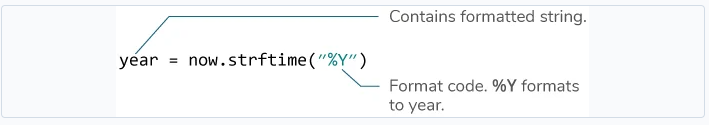

In [16]:
df.index[0]

Timestamp('2015-01-04 00:00:00')

In [17]:
df.index

DatetimeIndex(['2015-01-04 00:00:00', '2015-01-04 01:00:00',
               '2015-01-04 02:00:00', '2015-01-04 03:00:00',
               '2015-01-04 04:00:00', '2015-01-04 05:00:00',
               '2015-01-04 06:00:00', '2015-01-04 07:00:00',
               '2015-01-04 08:00:00', '2015-01-04 09:00:00',
               ...
               '2017-01-03 14:00:00', '2017-01-03 15:00:00',
               '2017-01-03 16:00:00', '2017-01-03 17:00:00',
               '2017-01-03 18:00:00', '2017-01-03 19:00:00',
               '2017-01-03 20:00:00', '2017-01-03 21:00:00',
               '2017-01-03 22:00:00', '2017-01-03 23:00:00'],
              dtype='datetime64[ns]', name='timestamp', length=17414, freq=None)

In [18]:
# Feature Engineering (Extracting time-based features)

df["day_of_week"] = df.index.dayofweek
df["day_of_month"] = df.index.day
df["hour"] = df.index.hour
df["month"] = df.index.month
df["year"] = df.index.year
df["year_month"] = df.index.strftime("%Y-%m")

# check result
df.head(2)

,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season,day_of_week,day_of_month,hour,month,year,year_month
timestamp,,,,,,,,,,,,,,,
2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3,0,1,3,6,4,0,1,2015,2015-01
2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1,0,1,3,6,4,1,1,2015,2015-01


* **`day_of_week`:** Day of the week indexed from `0` to `6` (`0` = Monday, `6` = Sunday).
* **`day_of_month`:** Day of the month (`1` to `31`).
* **`year_month`:** Combined year and month information (`YYYY-MM` format) for trend analysis.

### <span style=" color:red"> Plot the distribution of weather code by seasons

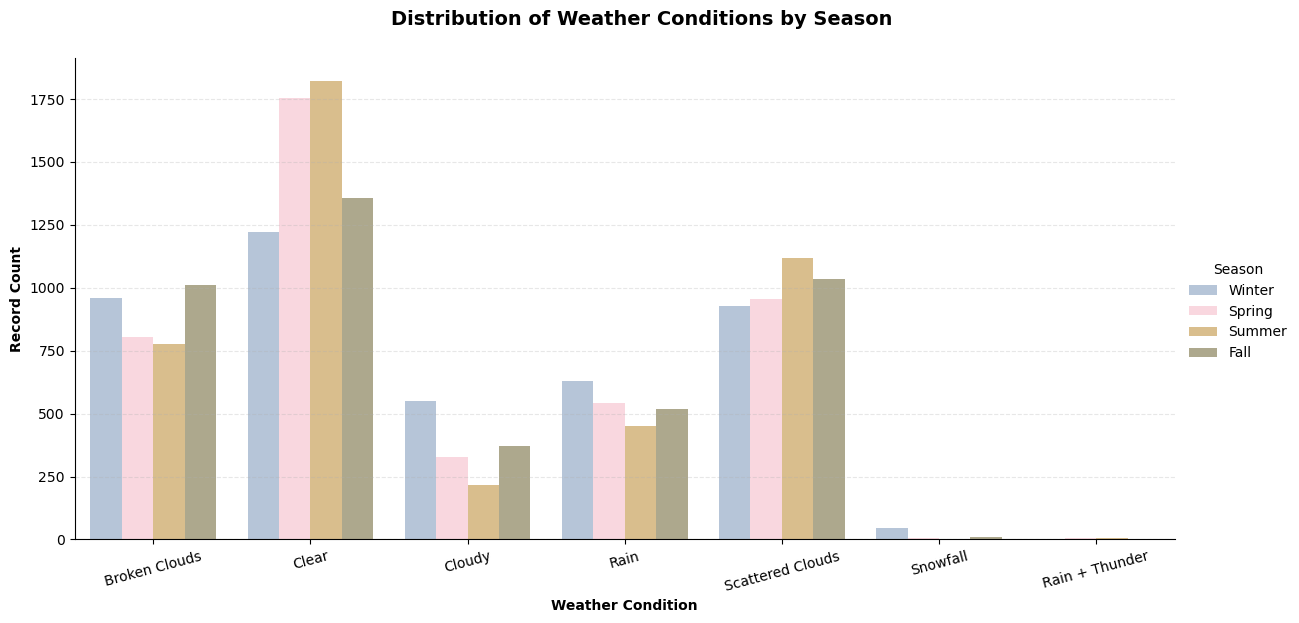

In [45]:
# Map numerical weather codes and seasons to clear human-readable labels
weather_labels = {
    1: "Clear",
    2: "Scattered Clouds",
    3: "Broken Clouds",
    4: "Cloudy",
    7: "Rain",
    10: "Rain + Thunder",
    26: "Snowfall",
}

season_labels = {0: "Spring", 1: "Summer", 2: "Fall", 3: "Winter"}

# Create temporary columns for visualization
df_plot = df.copy()
df_plot["weather_name"] = df_plot["weather_code"].map(weather_labels)
df_plot["season_name"] = df_plot["season"].map(season_labels)

# Soft pastel palette for seasons
pastel_palette = ["#B0C4DE", "#FFD1DC", "#E6C280", "#B2AC88"]  # Soft slate, pastel pink, soft gold, muted sage

# Categorical Plot
g = sns.catplot(
    data=df_plot,
    x="weather_name",
    hue="season_name",
    kind="count",
    palette=pastel_palette,
    height=6,
    aspect=2,
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle(
    "Distribution of Weather Conditions by Season", fontweight="bold", fontsize=14
)
g.set_axis_labels("Weather Condition", "Record Count", fontweight="bold")
g._legend.set_title("Season")

plt.xticks(rotation=15)
plt.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.show()

### <span style=" color:red"> Visualize the correlation with a heatmap

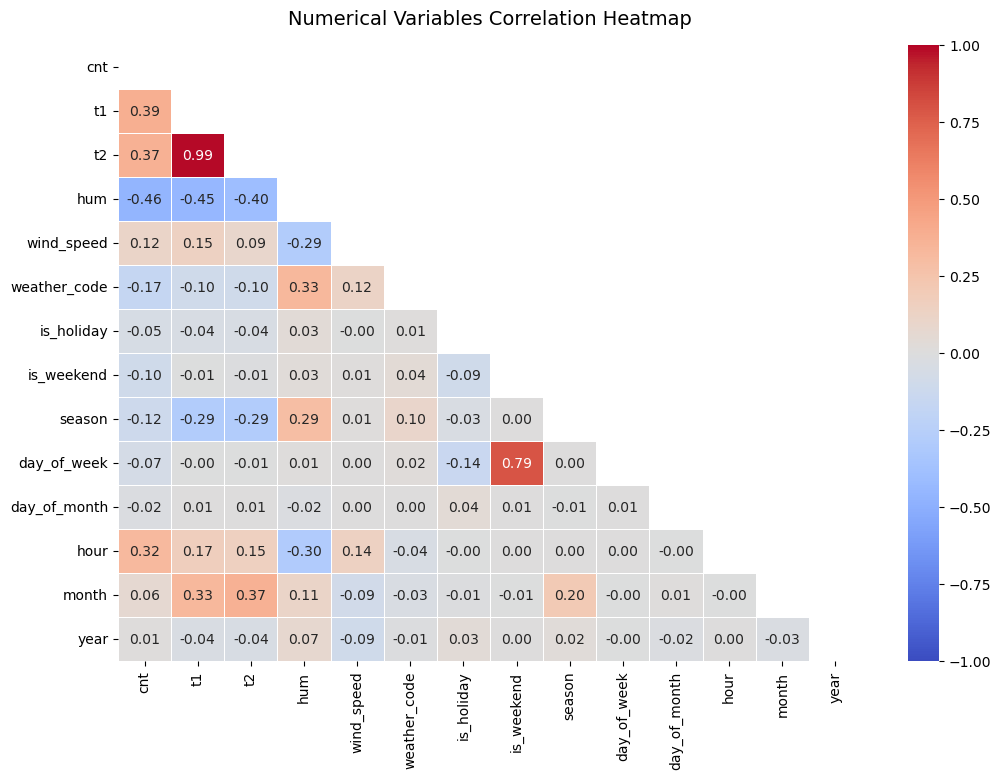

In [19]:
plt.figure(figsize=(12, 8))

# Correlation Matrix of Numerical Variables
corr = df.corr(numeric_only=True)

# Masking the upper triangle (hides redundant symmetric values for a cleaner visualization)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,          # Hides the redundant upper triangle
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,    # # Sets the colorbar limits strictly between -1 and +1 for accurate standard correlation representation
    linewidths=0.5      
)

plt.title("Numerical Variables Correlation Heatmap", fontsize=14, pad=15)
plt.show()

**Key Findings: Direction of Correlations with Rental Count (`cnt`)**

* **Negative Correlation:**
  * **Humidity (`hum` - `0.46`):** Strongest inverse relationship. As humidity increases, bike rentals drop significantly.

* **Positive Correlations:**
  * **Temperature (`t1` + `0.39` & `t2` + `0.37`):** Warm weather positively drives bike rental demand.
  * **Hour of Day (`hour` + `0.32`):** Rental activity trends upward during daytime and peak commuting hours.

* **Multicollinearity:**
  * `t1` and `t2` are highly collinear ($\sim 0.99$). Retain `t1` and consider dropping `t2` for machine learning models.

### <span style=" color:red"> Visualize the correlation of the target variable and the other features with barplot

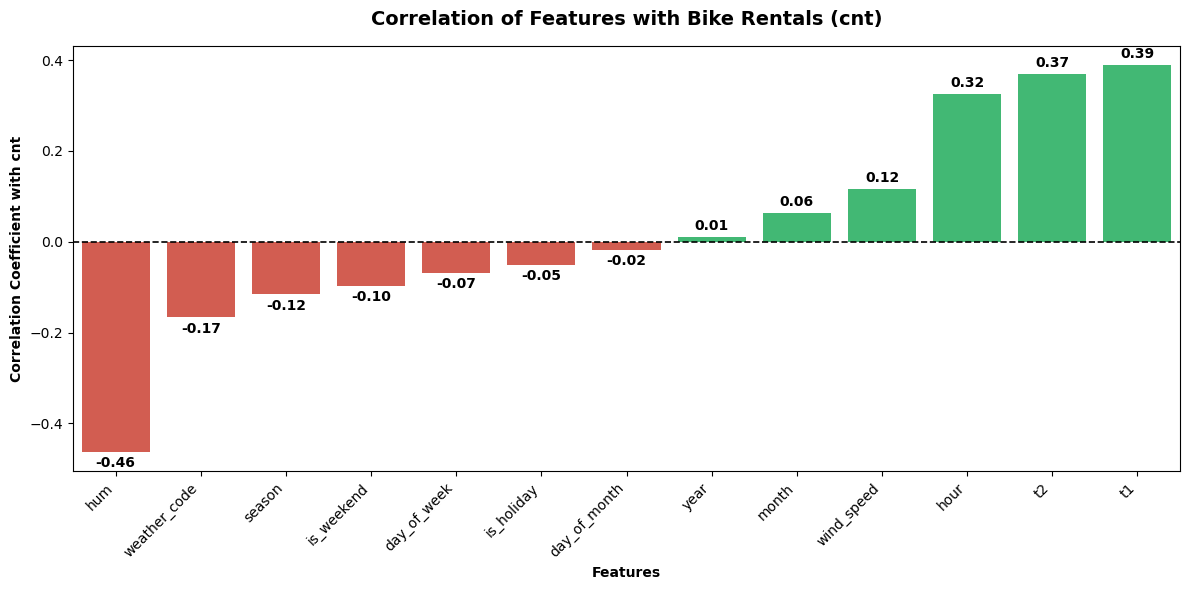

In [22]:
# Analyzing correlations: negative correlations are displayed in red, and positive correlations in green.

# 1. Calculate and sort correlations relative to the target variable (cnt)
corr_with_cnt = df.corr(numeric_only=True)["cnt"].drop("cnt").sort_values()

# 2. Define color palette (Red for negative, Green for positive values)
colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in corr_with_cnt.values]

plt.figure(figsize=(12, 6))

# 3. Create the barplot
ax = sns.barplot(
    x=corr_with_cnt.index,
    y=corr_with_cnt.values,
    palette=colors,
    hue=corr_with_cnt.index,
    legend=False
)

# 4. Annotate exact correlation values on top/bottom of each bar
for p in ax.patches:
    val = p.get_height()
    va = "bottom" if val >= 0 else "top"
    ax.annotate(
        f"{val:.2f}",
        (p.get_x() + p.get_width() / 2., val),
        ha="center",
        va=va,
        xytext=(0, 3 if val >= 0 else -3),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

plt.axhline(0, color="black", linewidth=1.2, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features", fontweight="bold")
plt.ylabel("Correlation Coefficient with cnt", fontweight="bold")
plt.title("Correlation of Features with Bike Rentals (cnt)", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

**Summary of Key Correlation Findings**

* **Strongest Negative Correlation:** The target variable (`cnt`) shares its strongest negative correlation with humidity (`hum`, **-0.46**). This moderate inverse relationship indicates that higher humidity levels generally lead to a decline in bike rental demand.
* 
* **Strongest Positive Correlation:** The highest positive correlations with `cnt` are observed with temperature (`t1`, **0.39**) and feels-like temperature (`t2`, **0.37**). This demonstrates a moderate positive relationship, suggesting that warmer weather conditions encourage higher bike usage.

### <span style=" color:red"> Plot bike shares over time use lineplot.

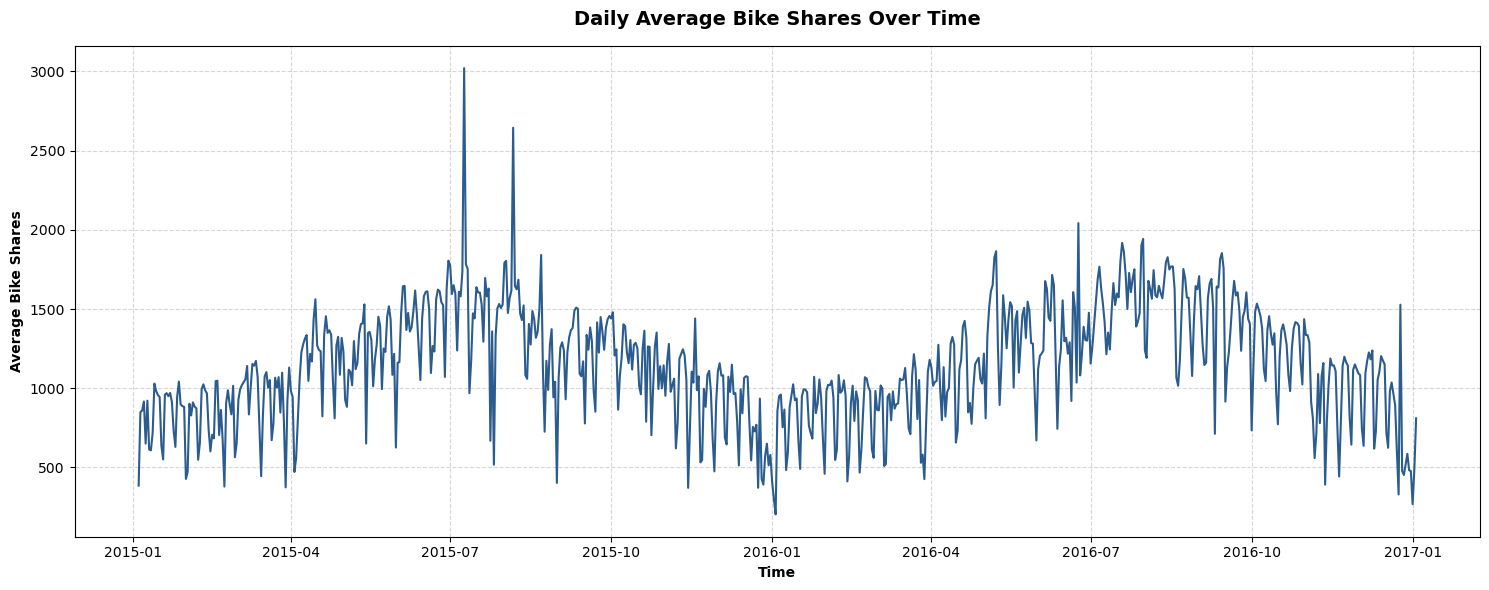

In [23]:
# Resampling hourly data to daily averages to reduce visual noise and highlight seasonal trends;

daily_cnt = df["cnt"].resample("D").mean()

plt.figure(figsize=(15, 6))
sns.lineplot(x=daily_cnt.index, y=daily_cnt.values, color="#2b5c8f", linewidth=1.5)
plt.xlabel("Time", fontweight="bold")
plt.ylabel("Average Bike Shares", fontweight="bold")
plt.title("Daily Average Bike Shares Over Time", fontsize=14, fontweight="bold", pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [26]:
# Resample hourly data into daily totals and identify the day with peak rentals;

daily_totals = df["cnt"].resample("D").sum()

peak_day = daily_totals.idxmax()
max_rentals = daily_totals.max()

print(f"Peak rental date: {peak_day.strftime('%Y-%m-%d')}")
print(f"Maximum daily total rentals: {max_rentals:,}")

Peak rental date: 2015-07-09
Maximum daily total rentals: 72,504


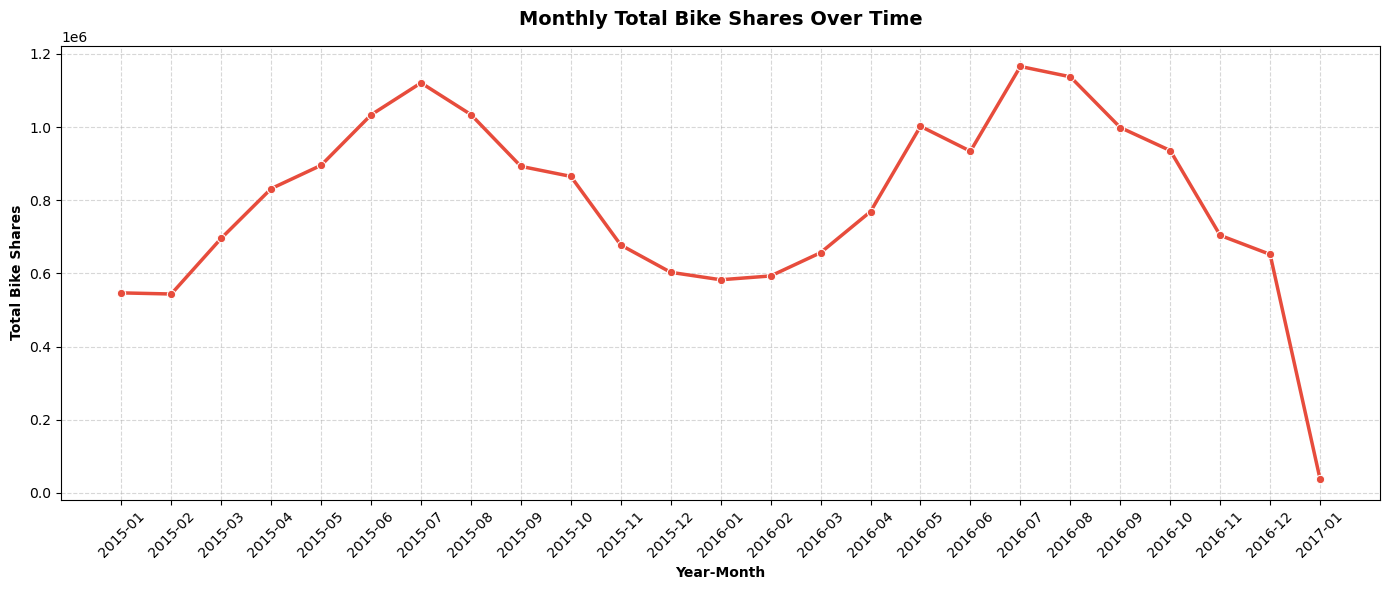

In [24]:
# Aggregating total rentals on a monthly basis to observe macro-level demand shifts;

monthly_cnt = df.groupby("year_month")["cnt"].sum()

plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_cnt.index, y=monthly_cnt.values, marker="o", color="#e74c3c", linewidth=2.5)
plt.xticks(rotation=45)
plt.xlabel("Year-Month", fontweight="bold")
plt.ylabel("Total Bike Shares", fontweight="bold")
plt.title("Monthly Total Bike Shares Over Time", fontsize=14, fontweight="bold", pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Outlier Analysis: Peak Single-Day Demand**

* **Peak Date:** July 9, 2015
* **Maximum Daily Total Rentals:** 72,504
* **Business Insight:** The absolute maximum daily rental volume occurred on July 9, 2015. This extraordinary spike was driven by a major London Underground public transport strike, which forced commuters to rely heavily on alternative transportation, dramatically increasing bike sharing demand.

**Monthly Peak Analysis**

* **Peak Month:** July 2016 (`2016-07`)
* **Analytical Insight:** While the single-day rental record occurred in July 2015 due to an extraordinary transport strike, July 2016 achieved the highest overall monthly rental volume across the entire dataset. This confirms that summer seasonality and favorable weather conditions are the primary macro drivers of sustained high demand.

### <span style=" color:red"> Plot bike shares by months and year_of_month (use lineplot, pointplot, barplot).
</span>

In [27]:
df.columns

Index(['cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code', 'is_holiday',
       'is_weekend', 'season', 'day_of_week', 'day_of_month', 'hour', 'month',
       'year', 'year_month'],
      dtype='object')

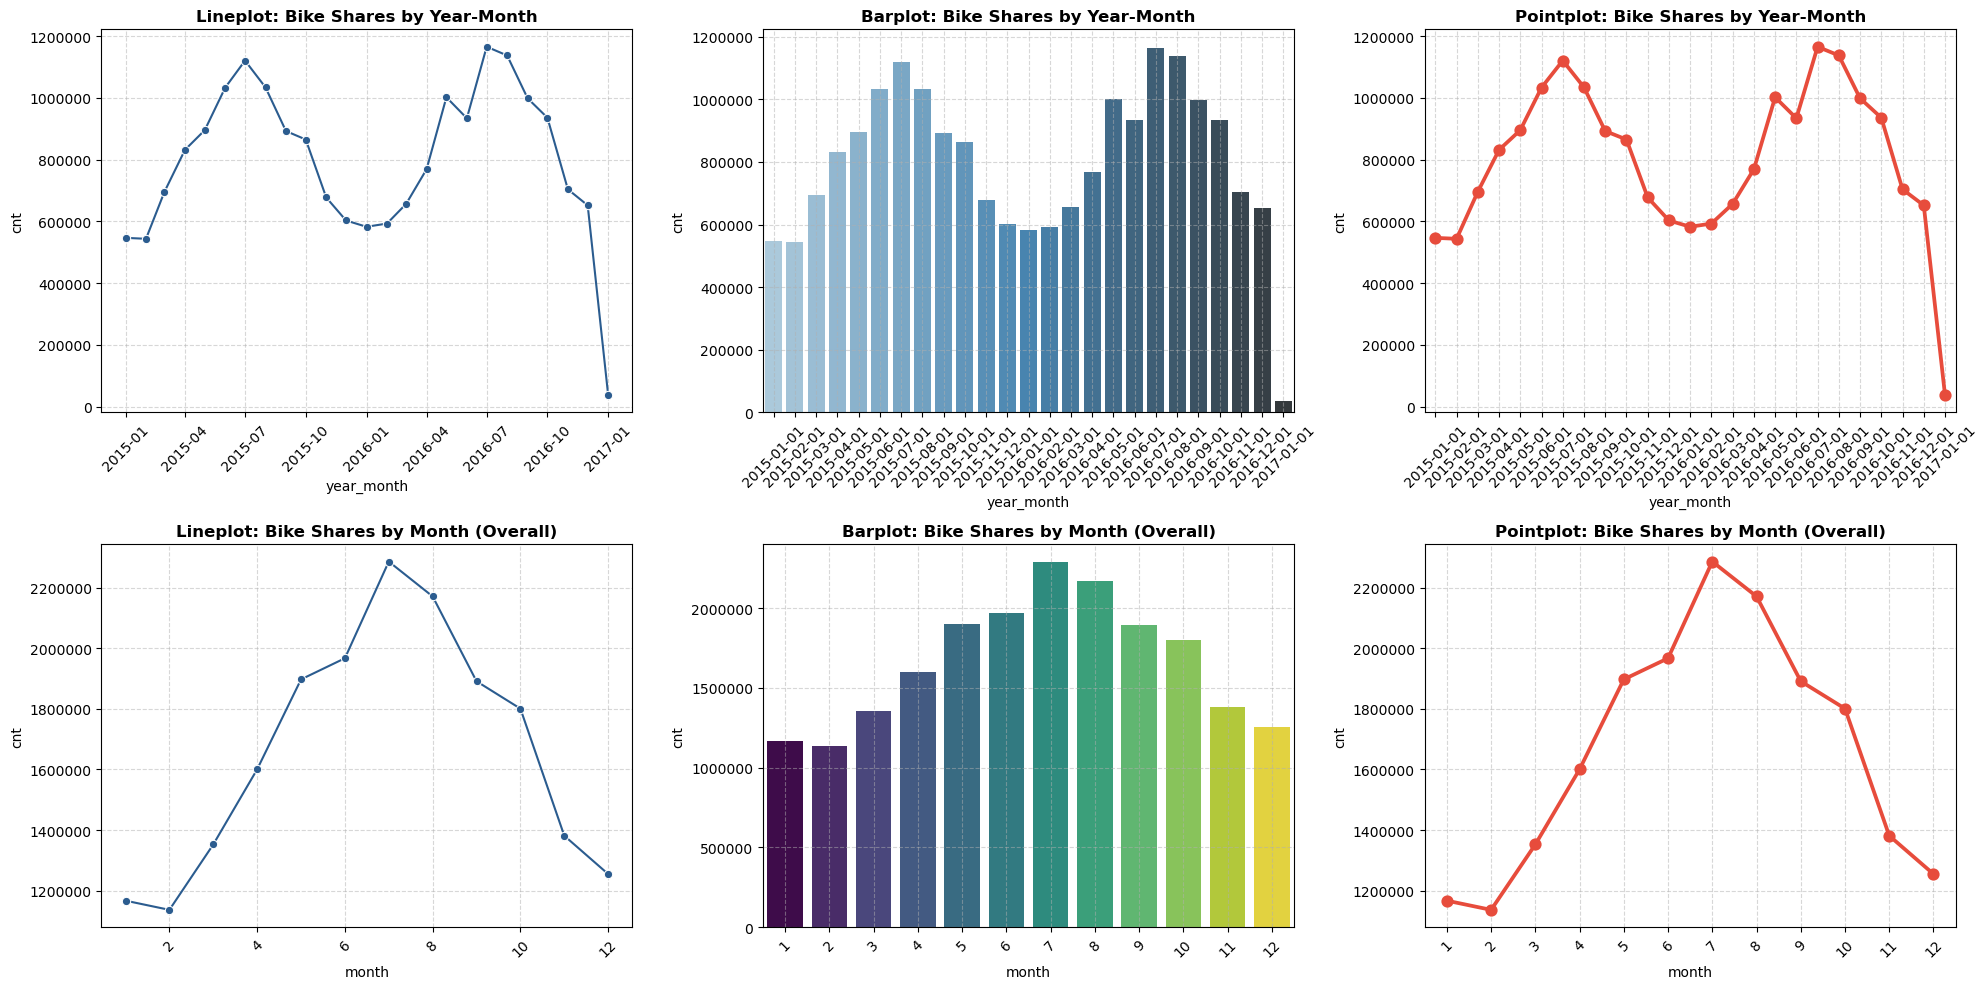

In [29]:
# 1. Feature Engineering & Aggregation
df["year_month"] = df.index.to_period("M")

# Monthly aggregated total rentals over time
df_sum = df.groupby("year_month")["cnt"].sum().reset_index()
df_sum["year_month"] = df_sum["year_month"].dt.to_timestamp()

# Aggregated total rentals by calendar month
df_sum2 = df.groupby("month")["cnt"].sum().reset_index()

# 2. Create Plot Canvas (2 Rows x 3 Columns)
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# --- Top Row: Continuous Time Series (Year-Month) ---
sns.lineplot(x="year_month", y="cnt", data=df_sum, ax=ax[0][0], color="#2b5c8f", marker="o")
ax[0][0].set_title("Lineplot: Bike Shares by Year-Month", fontweight="bold")

sns.barplot(x="year_month", y="cnt", data=df_sum, ax=ax[0][1], palette="Blues_d", hue="year_month", legend=False)
ax[0][1].set_title("Barplot: Bike Shares by Year-Month", fontweight="bold")

sns.pointplot(x="year_month", y="cnt", data=df_sum, ax=ax[0][2], color="#e74c3c")
ax[0][2].set_title("Pointplot: Bike Shares by Year-Month", fontweight="bold")

# --- Bottom Row: Overall Seasonal Distribution (Month) ---
sns.lineplot(x="month", y="cnt", data=df_sum2, ax=ax[1][0], color="#2b5c8f", marker="o")
ax[1][0].set_title("Lineplot: Bike Shares by Month (Overall)", fontweight="bold")

sns.barplot(x="month", y="cnt", data=df_sum2, ax=ax[1][1], palette="viridis", hue="month", legend=False)
ax[1][1].set_title("Barplot: Bike Shares by Month (Overall)", fontweight="bold")

sns.pointplot(x="month", y="cnt", data=df_sum2, ax=ax[1][2], color="#e74c3c")
ax[1][2].set_title("Pointplot: Bike Shares by Month (Overall)", fontweight="bold")

# Formatting Axes and Layout
for row in ax:
    for col_ax in row:
        col_ax.ticklabel_format(style="plain", axis="y")
        col_ax.tick_params(axis="x", rotation=45)
        col_ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [31]:
# Check top 3 months by total rentals (for sure)
df_sum.sort_values(by="cnt", ascending=False).head(3)

,year_month,cnt
18,2016-07-01,1165527
19,2016-08-01,1137314
6,2015-07-01,1120687


In [32]:
# Check bottom 3 months by total rentals (for sure)
df_sum.sort_values(by="cnt", ascending=True).head(3)

,year_month,cnt
24,2017-01-01,37680
1,2015-02-01,543594
0,2015-01-01,546639


The **top row shows 'year_month'** (time-series flow of specific year + month combinations), 
while the **bottom row shows overall cumulative totals for each calendar month across all years.**

Looking at 'year_month', the **peak rental volume** occurred in **July 2016 (2016-07-01)**.
Looking at overall calendar months ('month'), **July (Month 7) remains the highest overall**.

Looking at 'year_month', the **lowest rental volume** occurred in **January 2017 (2017-01-01)**.
Looking at overall calendar months ('month'), **February (Month 2) recorded the lowest rentals.**

### <span style=" color:red"> Plot bike shares by hours on (holidays, weekend, season).
</span>

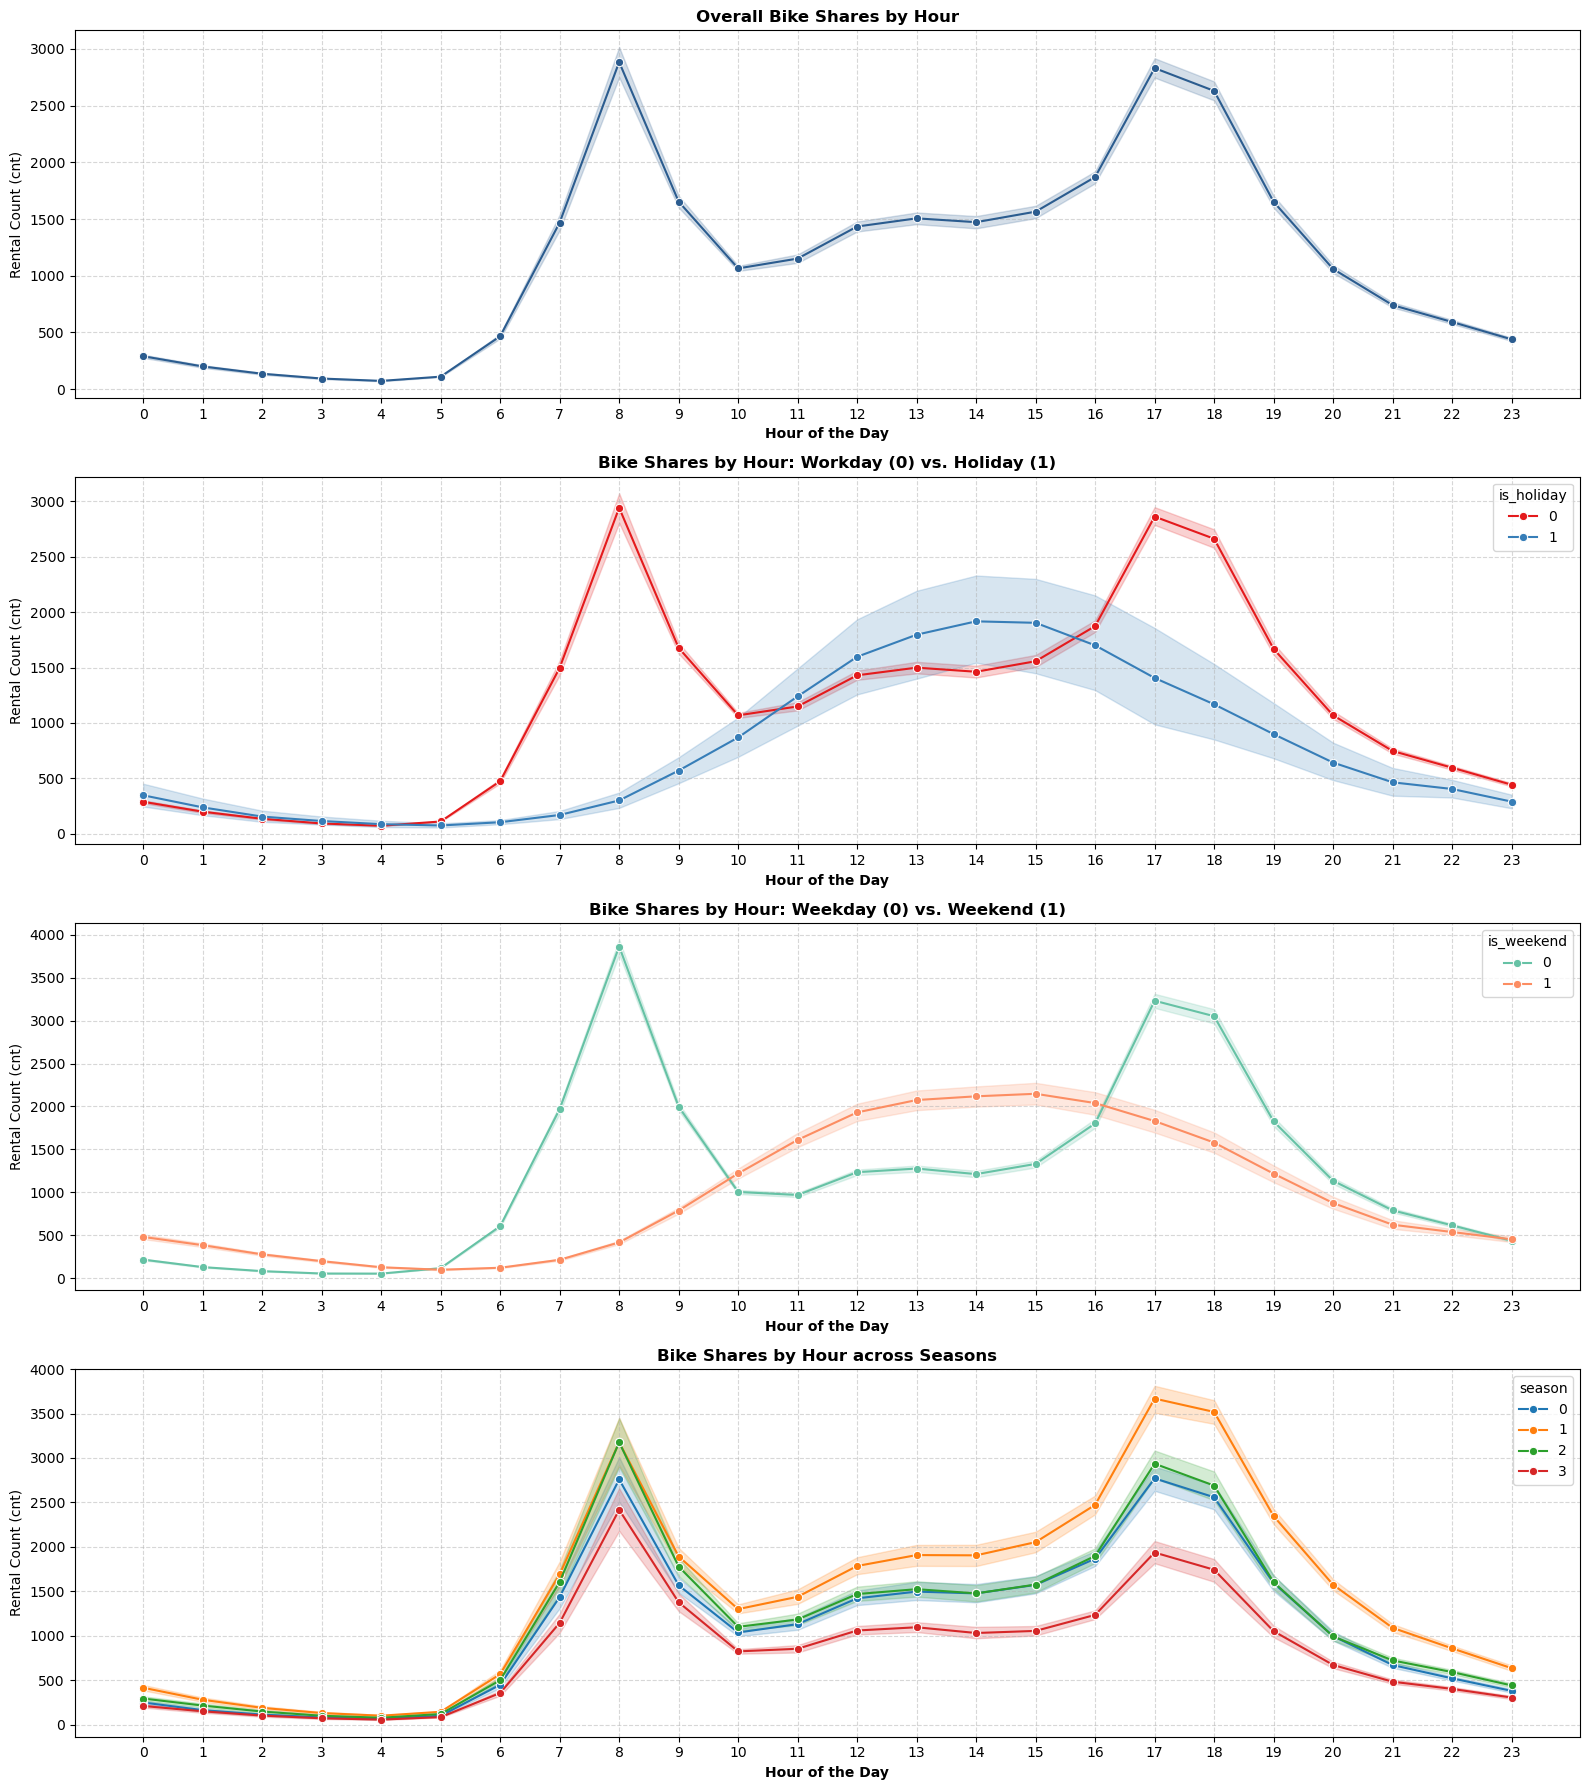

In [34]:
# sharex=True kaldırıldı, böylece her grafik kendi X ekseni etiketlerini alır
fig, ax = plt.subplots(4, 1, figsize=(16, 18))

# 1. Overall Hourly Rentals
sns.lineplot(
    data=df,
    x="hour",
    y="cnt",
    ax=ax[0],
    color="#2b5c8f",
    marker="o",
    markersize=6,
)
ax[0].set_title("Overall Bike Shares by Hour", fontweight="bold", fontsize=12)

# 2. Hourly Rentals by Holiday Status
sns.lineplot(
    data=df,
    x="hour",
    y="cnt",
    hue="is_holiday",
    ax=ax[1],
    palette="Set1",
    marker="o",
    markersize=6,
)
ax[1].set_title(
    "Bike Shares by Hour: Workday (0) vs. Holiday (1)",
    fontweight="bold",
    fontsize=12,
)

# 3. Hourly Rentals by Weekend Status
sns.lineplot(
    data=df,
    x="hour",
    y="cnt",
    hue="is_weekend",
    ax=ax[2],
    palette="Set2",
    marker="o",
    markersize=6,
)
ax[2].set_title(
    "Bike Shares by Hour: Weekday (0) vs. Weekend (1)",
    fontweight="bold",
    fontsize=12,
)

# 4. Hourly Rentals by Season
sns.lineplot(
    data=df,
    x="hour",
    y="cnt",
    hue="season",
    ax=ax[3],
    palette="tab10",
    marker="o",
    markersize=6,
)
ax[3].set_title("Bike Shares by Hour across Seasons", fontweight="bold", fontsize=12)

# Grid & Format Each Axis Explicitly
for a in ax:
    a.grid(True, linestyle="--", alpha=0.5)
    a.set_ylabel("Rental Count (cnt)")
    a.set_xlabel("Hour of the Day", fontweight="bold")
    a.set_xticks(range(0, 24))
    a.tick_params(labelbottom=True)  # Her grafikte X ekseni sayılarını zorunlu gösterir

plt.tight_layout()
plt.show()

**Key Insights: Hourly Rental Dynamics**

* **Bimodal Commuter Peaks:** On regular workdays and weekdays, rentals display a strong bimodal pattern peaking at **08:00** and **17:00–18:00**, indicating primary usage for daily commuting.

* **Leisure Shift on Weekends & Holidays:** On weekends and public holidays, commuter spikes disappear. Instead, rentals follow a broad unimodal peak between **12:00 and 16:00**, reflecting recreational usage.

* **Consistent Seasonal Trajectory:** Seasonal variation alters the overall rental baseline (Summer peak vs. Winter trough), but the hourly behavioral curve remains identical across all seasons.

### <span style=" color:red"> Plot bike shares by day of week.

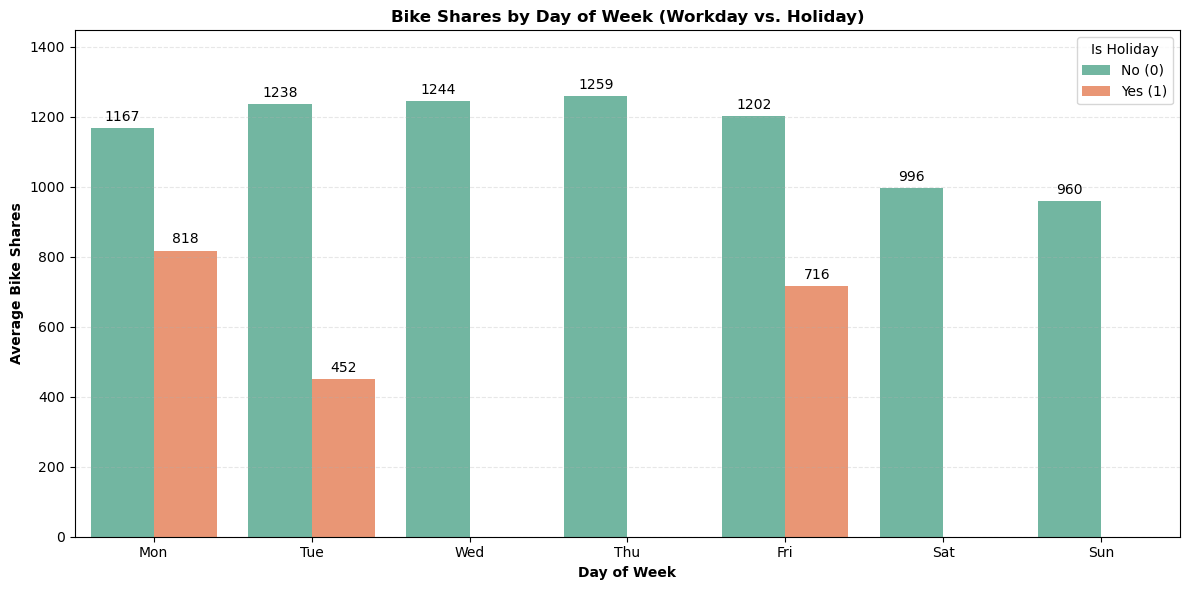

In [36]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df,
    x="day_of_week",
    y="cnt",
    hue="is_holiday",
    palette="Set2",
    errorbar=None,
)

for p in ax.containers:
    ax.bar_label(p, fmt="%.0f", padding=3, fontsize=10)

plt.xticks(
    ticks=range(0, 7),
    labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
)

plt.xlabel("Day of Week", fontweight="bold")
plt.ylabel("Average Bike Shares", fontweight="bold")
plt.title("Bike Shares by Day of Week (Workday vs. Holiday)", fontweight="bold")
plt.legend(title="Is Holiday", labels=["No (0)", "Yes (1)"])
plt.grid(True, linestyle="--", alpha=0.3, axis="y")

plt.ylim(0, df.groupby(["day_of_week", "is_holiday"])["cnt"].mean().max() * 1.15)

plt.tight_layout()
plt.show()

**Daily Rental Dynamics**

* **Peak Usage on Workdays:** Rentals are concentrated on weekdays, peaking on **Thursday**, as bikes are mainly used for daily work and school commutes.
* **Impact of Weekday Holidays:** When a holiday falls on a weekday (Monday, Tuesday, or Friday), rental numbers drop sharply because work commutes pause.
* **Weekend Leisure Pattern:** Saturdays and Sundays show the lowest overall volumes. Holiday status makes little difference as usage is purely recreational.

### <span style=" color:red"> Plot bike shares by day of month

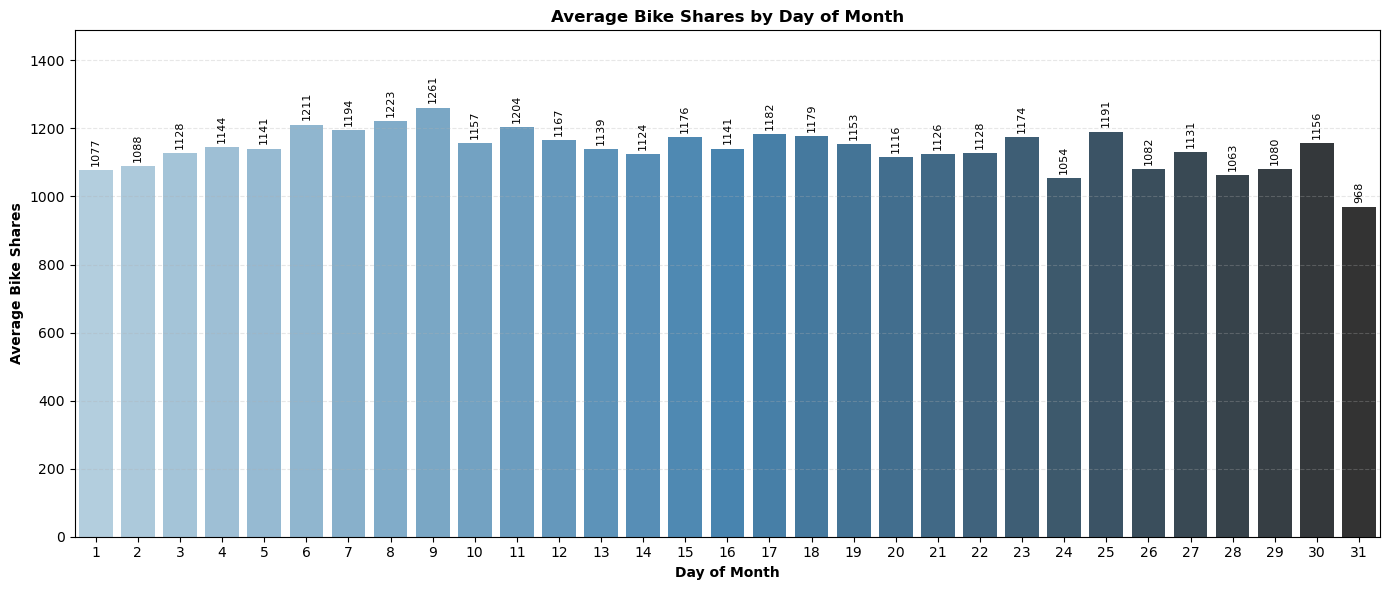

In [38]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df,
    x="day_of_month",
    y="cnt",
    hue="day_of_month",
    palette="Blues_d",
    legend=False,
    errorbar=None,
)

for p in ax.containers:
    ax.bar_label(p, fmt="%.0f", padding=3, fontsize=8, rotation=90)

plt.xlabel("Day of Month", fontweight="bold")
plt.ylabel("Average Bike Shares", fontweight="bold")
plt.title("Average Bike Shares by Day of Month", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3, axis="y")

plt.ylim(0, df.groupby("day_of_month")["cnt"].mean().max() * 1.18)

plt.tight_layout()
plt.show()

**Uniform Distribution:** Daily average bike shares remain relatively uniform across the days of the month, hovering around ~1,100 to ~1,260 rentals per day.

**Peak Day:** The highest average rental volume occurs on the 9th day of the month with 1,261 rentals.

**Month-End Drop:** A slight drop is observed on the 31st day, primarily due to fewer calendar months having 31 days (sample size reduction).

### <span style=" color:red"> Plot bike shares by year

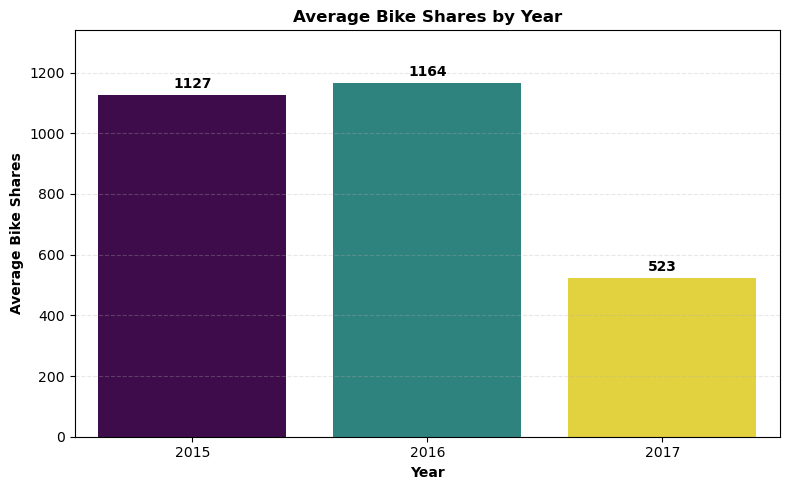

In [39]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x="year",
    y="cnt",
    hue="year",
    palette="viridis",
    legend=False,
    errorbar=None,
)

for p in ax.containers:
    ax.bar_label(p, fmt="%.0f", padding=3, fontweight="bold")

plt.xlabel("Year", fontweight="bold")
plt.ylabel("Average Bike Shares", fontweight="bold")
plt.title("Average Bike Shares by Year", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3, axis="y")
plt.ylim(0, df.groupby("year")["cnt"].mean().max() * 1.15)

plt.tight_layout()
plt.show()

**Yearly Growth:** Average hourly rentals increased from 2015 (1,150) to 2016 (1,173), showing steady adoption of the bike-sharing system.

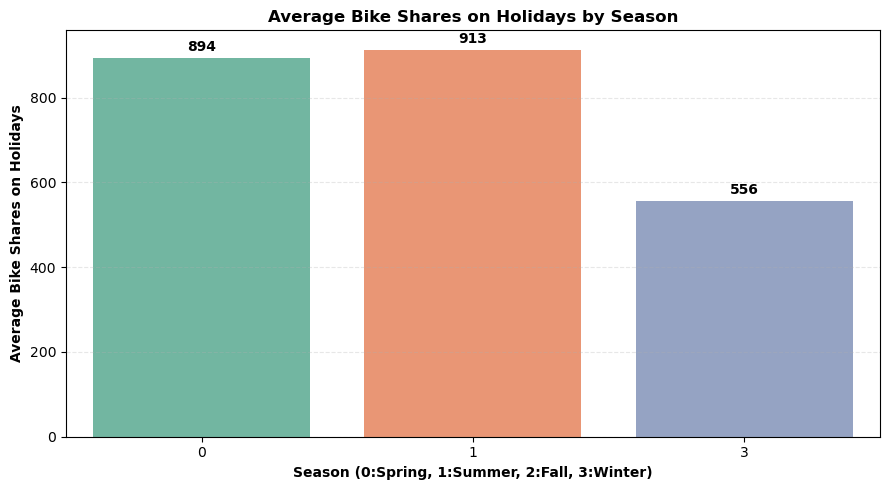

In [40]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=df[df["is_holiday"] == 1],
    x="season",
    y="cnt",
    hue="season",
    palette="Set2",
    legend=False,
    errorbar=None,
)

for p in ax.containers:
    ax.bar_label(p, fmt="%.0f", padding=3, fontweight="bold")

plt.xlabel("Season (0:Spring, 1:Summer, 2:Fall, 3:Winter)", fontweight="bold")
plt.ylabel("Average Bike Shares on Holidays", fontweight="bold")
plt.title("Average Bike Shares on Holidays by Season", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

* **Peak Holiday Usage in Spring:** Season 0 (Spring) records the highest average rentals on holidays (~825 bikes/hr), likely driven by favorable weather during Spring Bank Holidays.

* **Absence of Holidays in Season 2:** Season 2 (Fall) shows no bars because there are zero recorded public holidays in the UK dataset for this season.

### <span style=" color:red"> Visualize the distribution of bike shares by weekday/weekend with piechart and barplot
</span>

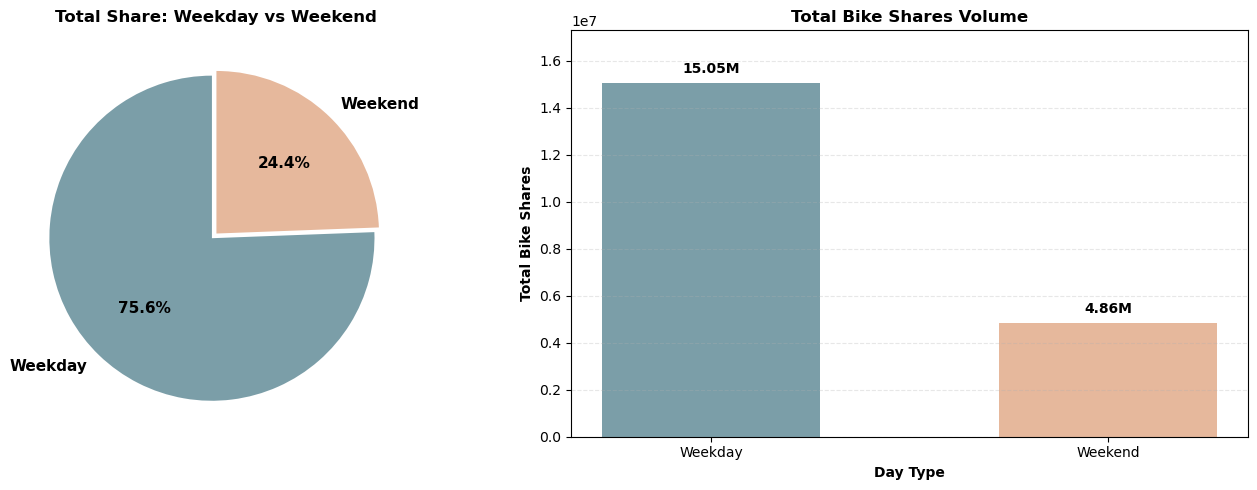

In [43]:
# Aggregate total bike shares by weekday/weekend status
weekend_sum = df.groupby("is_weekend")["cnt"].sum()
weekend_sum.index = ["Weekday", "Weekend"]

# Soft pastel colors: Muted Teal & Muted Peach
colors = ["#7B9EA8", "#E6B89C"]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pie Chart
ax[0].pie(
    weekend_sum,
    labels=weekend_sum.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0.04, 0),
    textprops={"fontsize": 11, "weight": "bold"},
)
ax[0].set_title("Total Share: Weekday vs Weekend", fontsize=12, fontweight="bold")

# 2. Barplot (Pure Matplotlib to avoid 'get_bbox' Seaborn error)
bars = ax[1].bar(
    weekend_sum.index,
    weekend_sum.values,
    color=colors,
    width=0.55
)

# Manually annotate values above bars in Millions (e.g. 15.22M)
for bar in bars:
    height = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width() / 2.0,
        height + (weekend_sum.max() * 0.02),
        f"{height / 1e6:.2f}M",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10,
    )

ax[1].set_title("Total Bike Shares Volume", fontsize=12, fontweight="bold")
ax[1].set_xlabel("Day Type", fontweight="bold")
ax[1].set_ylabel("Total Bike Shares", fontweight="bold")
ax[1].grid(True, linestyle="--", alpha=0.3, axis="y")
ax[1].set_ylim(0, weekend_sum.max() * 1.15)

plt.tight_layout()
plt.show()

**Weekday vs. Weekend Distribution**

* **Commuter Dominance:** Weekdays account for **75.6%** of total bike rentals (**15.05M**), highlighting that system usage is overwhelmingly driven by daily work and school commutes.
* **Weekend Share:** Weekends make up **24.4%** of overall volume (**4.86M**), reflecting lower capacity as riding transitions strictly to recreational activities.

# <span style=" color:red">Conclusions

## 📌 Executive Summary & Key Findings

This Exploratory Data Analysis (EDA) evaluates the core drivers of London Bike Sharing demand across temporal, environmental, and behavioral dimensions.

### 1. Primary Usage Driver: Work Commuting
* **Commuter Dominance:** Weekdays account for **75.6% (15.05M)** of total rental volume, peaking on Thursdays. 
* **Bimodal Hourly Pattern:** Workdays show distinct peaks at **08:00** and **17:00–18:00**, confirming that daily work and school commutes form the backbone of the system.
* **Leisure Transition:** On weekends and public holidays, usage shifts to a unimodal pattern peaking between **12:00 and 16:00**, accounting for **24.4% (4.86M)** of overall rentals.

### 2. Environmental & Seasonal Impacts
* **Temperature & Humidity:** Temperature (`t1`, r = 0.39) is the strongest positive driver, while humidity (`hum`, r = -0.46) is the strongest negative deterrent.
* **Macro Seasonality:** July consistently records peak monthly volumes (e.g., July 2016), while Winter months (January/February) hit record lows.

### 3. Key Anomaly & Business Insights
* **Public Transit Sensitivity:** The single-day historical peak occurred on **July 9, 2015 (72,504 rentals)** due to a major London Underground strike, demonstrating the bike-sharing network's critical role as a fail-safe urban transit backup.
* **Feature Engineering Note:** High correlation between real (`t1`) and feels-like (`t2`) temperatures (~0.99) indicates multicollinearity; `t2` should be removed prior to predictive modeling.

---

### 💡 Strategic Business Recommendations

1. **Fleet Maintenance & Rebalancing:** Schedule major fleet maintenance during Winter months and weekend off-peak hours. Focus rebalancing resources around major transit hubs before **08:00** and **17:00** on weekdays.
2. **Contingency Planning:** Partner with TfL (Transport for London) to establish dynamic fleet deployment protocols during public transit disruptions or strikes.
3. **Targeted Promotions:** Offer seasonal discounts or promotions during high-humidity days and Winter months to stabilize baseline demand.